In [1]:
import backmapping_funcs as bm
import CarbonaraDataTools as cdt
import fittingAnalysis as fa
import numpy as np
import os
import json
import pickle
import sys
sys.path.insert(0, "./_local_pkgs")


First set up the directory

In [2]:
# Specify the directory to search replace with what ever you set run_name as

directory = 'carbonara_runs/IZZY_MOL/'
run = "fitdata"


In [3]:
# check the number of independent fitting runs

fa.count_fitting_runs(directory+run)

'There are 20 independent fitting runs for this molecule.'

If you want to apply the all atom backmappingh the last predictions of the run execute the code below

In [ ]:
# if the all atom structures weren't constructed in real time then recreate them here. You should expect output as shown below

bm.generateAllAtomisticFits(directory,run,threshold="last",rateIn= "fast")

In [4]:
view =  fa.visualisePrediction(directory+run,20)

Using latest prediction: 14


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [4]:
pdbs = fa.collect_final_predictions_test(directory+run)

In [9]:
rmsdPairedComparisons = fa.pairwise_structure_metrics(
    pdbs,
    fa.compare_structures_vals
)

Pairwise comparisons: 100%|█████████████████████████████████████████████████████████████████| 190/190 [02:50<00:00,  1.11pair/s]


In [7]:
originalPdb = "pdbFiles/h1K222C.pdb"

rmsdToOriginal = fa.structure_metrics_vs_carbonara(
    pdb_files=pdbs,
    carbonara_dir=directory,
    compare_func=fa.compare_structures_vals_carbonara
)

Comparisons vs Carbonara: 100%|███████████████████████████████████████████████████████████████| 20/20 [00:08<00:00,  2.31pair/s]


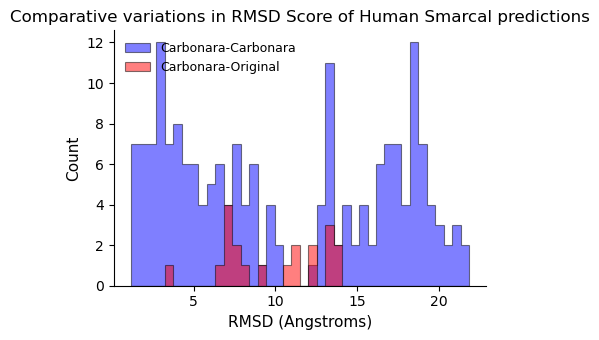

In [11]:
metric = "rmsd"
#could be 'tm' or 'gdt_ts'


fa.plot_overlaid_histograms([rmsdPairedComparisons,rmsdToOriginal],
    "rmsd",
    ["Carbonara-Carbonara","Carbonara-Original"],
    "RMSD (Angstroms)",
    "Comparative variations in RMSD Score of Human Smarcal predictions",
    bins=40,
    figsize=(4.5, 3.5),
    colors=["blue","red"],
    alpha=0.5,
    density=False,
    dpi=300
)

In [8]:
# you can look in the variation in Radius of Gyration also

rg_results = fa.calc_rg_distribution(
    pdb_files=pdbs,
    rg_func=fa.radius_of_gyration,
    weighted=False
)

# if its a mixture we can do the weighted Rg

#mixture_dict = {(runNo, "end"): mix for runNo, mix in zip(runNos, mixtures)}

#rg_results = calc_rg_distribution(
#    pdb_files=pdbs,
#    rg_func=fa.radius_of_gyration,
#    weighted=True,
#    mixtures=mixture_dict
#)

# lets do the og pdb
originalPdb = "pdbFiles/h1K222C.pdb"

rg_results_og = fa.calc_rg_distribution(
    pdb_files=[originalPdb],
    rg_func=fa.radius_of_gyration,
    weighted=False
)


Calculating Rg: 100%|████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.32pdb/s]


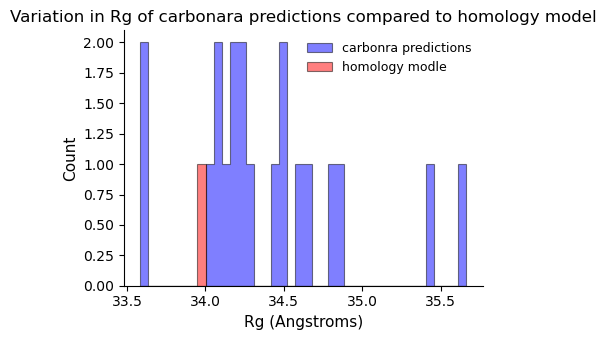

In [9]:
metric = "rg"
#could be 'tm' or 'gdt_ts'


fa.plot_overlaid_histograms([rg_results,rg_results_og],
    metric,
    ["carbonra predictions","homology modle"],
    "Rg (Angstroms)",
    "Variation in Rg of carbonara predictions compared to homology model",
    bins=40,
    figsize=(4.5, 3.5),
    colors=["blue","red"],
    alpha=0.5,
    density=False,
    dpi=300
)

In [14]:
rgvals = [fa.radius_of_gyration(pdb) for pdb in pdbs]

In [ ]:
# load the runs in
predictions = fa.load_runs_DF(directory+run)

In [ ]:
# look a the all atomistic scattering as a function of time
fa.plot_vars([predictions[3],predictions[27]], "ElapsedTimeMin", "ScatteringValue",title="Scattering value vs elapsed time",x_label="Time in minutes",y_label="Chi-Squared value", kind='line',legend_labels=["Run 3","Run 27"])

In [ ]:
view =  fa.visualisePrediction(directory+run,3, predNo=0)

In [ ]:
cdt.SAXS_fit_plotter(os.path.join(directory,"Saxs.dat"),os.path.join(directory+run,f"mol{1}_step_{1}_scatter.dat"), full_q=True)

In [ ]:
runNo1 = 4
runNo2 = 4
predNo1 = 2
predNo2 = 2
subNo1 = 0
subNo2 = 1
print(fa.compare_structures_vals(os.path.join(directory,run,"allAtomRun"+str(runNo1),f"mol{runNo1}_sub_{subNo1}_step_{predNo1}__AA.pdb"),os.path.join(directory,run,"allAtomRun"+str(runNo2),f"mol{runNo2}_sub_{subNo2}_step_{predNo2}__AA.pdb")))
view =  fa.visualisePredictionComparison(directory+run,runNo1,runNo2,predNo1,predNo2, subNo1,subNo2)

In [ ]:
# collet the mixture precentages and end pdbs's

#mixtures, runNos  = fa.collect_end_scatter_mixtures_ordered(directory+run)
